<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
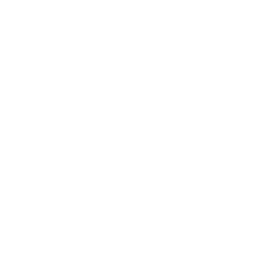
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Import van Centrale Klinische Laboratoriumresultaten</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Farmaceutica / Biostatistiek &nbsp;|&nbsp; maart 2026</p>
</div>
</div>
</div>

## Managementsamenvatting

Importeer een CSV-bestand van een centraal laboratorium met klinisch-chemische
en hematologische panels voor een fase II-oncologiestudie. Gebruik
GUESSINGROWS=MAX om ervoor te zorgen dat variabeletypen correct worden
afgeleid over de volledige dataset, zodat ijle numerieke velden niet ten
onrechte als tekst worden geclassificeerd. Voer de geïmporteerde dataset in
PROC MEANS met ODS OUTPUT in om referentiebereik-samenvattingsstatistieken te
genereren, gestratificeerd naar analyt en bezoek, ter ondersteuning van de
beoordeling van labnormaalwaarden door de medisch monitor.

## Gegevensbronnen

| Bron | Beschrijving | Records |
|--------|-------------|--------|
| central_lab_results.csv | CSV-export van het centrale laboratorium met chemie- en hematologiepanels | ~5.000 (ontworpen); 100 in licentievrije modus |
| WORK.LAB_IMPORT | Geïmporteerde SAS-dataset van PROC IMPORT | ~5.000 (ontworpen); 100 in licentievrije modus |

De runtime draait in de licentievrije modus, die de invoer en uitvoer begrenst
tot 100 waarnemingen in plaats van de ontworpen 5.000; de cijfers in de
interpretatie hieronder weerspiegelen deze steekproef van 100 rijen.

---

In [1]:
/* --------------------------------------------------------
   Genereer synthetisch CSV-bestand van het centrale laboratorium
   Kolommen: USUBJID, VISIT, LBTESTCD, LBTEST, LBCAT,
            LBORRES, LBORRESU, LBORNRLO, LBORNRHI,
            LBSTRESN, LBSTRESC, LBBLFL, LBDTC
   -------------------------------------------------------- */
GEGEVENS work.lab_csv_source;
    CALL streaminit(42);
    LENGTE usubjid $16 visit $25 lbtestcd $8 lbtest $35
           lbcat $20 lborres $12 lborresu $10
           lbornrlo $8 lbornrhi $8 lbstresc $12
           lbblfl $1 lbdtc $10;
    REEKS test_codes[8] $8 _temporary_
        ('ALT' 'AST' 'BILI' 'CREAT' 'ALB' 'HGB' 'WBC' 'PLT');
    REEKS test_names[8] $35 _temporary_
        ('Alanine-aminotransferase' 'Aspartaataminotransferase'
         'Bilirubine' 'Creatinine' 'Albumine'
         'Hemoglobine' 'Witte bloedcellen' 'Bloedplaatjes');
    REEKS test_cats[8] $20 _temporary_
        ('CHEMIE' 'CHEMIE' 'CHEMIE' 'CHEMIE'
         'CHEMIE' 'HEMATOLOGIE' 'HEMATOLOGIE' 'HEMATOLOGIE');
    REEKS test_units[8] $10 _temporary_
        ('U/L' 'U/L' 'mg/dL' 'mg/dL' 'g/dL' 'g/dL' '10^3/uL' '10^3/uL');
    REEKS lo_norm[8] _temporary_ (7 8 0.1 0.6 3.5 12.0 4.0 150);
    REEKS hi_norm[8] _temporary_ (56 40 1.2 1.2 5.5 17.5 11.0 400);
    REEKS visit_list[5] $25 _temporary_
        ('SCREENING' 'CYCLUS 1 DAG 1' 'CYCLUS 2 DAG 1'
         'CYCLUS 3 DAG 1' 'EINDE BEHANDELING');
    DOE subj = 1 TOT 125;
        usubjid = cat('ONC-2026-', put(subj, z4.));
        DOE v = 1 TOT 5;
            visit = visit_list[v];
            DOE t = 1 TOT 8;
                lbtestcd = test_codes[t];
                lbtest = test_names[t];
                lbcat = test_cats[t];
                lborresu = test_units[t];
                mid = (lo_norm[t] + hi_norm[t]) / 2;
                spread = (hi_norm[t] - lo_norm[t]) / 4;
                lbstresn = round(rand('normal', mid, spread), 0.01);
                ALS lbstresn < 0 DAN lbstresn = 0.01;
                lborres = put(lbstresn, 8.2);
                lbstresc = lborres;
                lbornrlo = put(lo_norm[t], 8.2);
                lbornrhi = put(hi_norm[t], 8.2);
                ALS v = 1 DAN lbblfl = 'Y';
                ANDERS lbblfl = '';
                base_date = '01JAN2026'd + (v - 1) * 21
                    + int(rand('uniform') * 3);
                lbdtc = put(base_date, yymmdd10.);
                UITVOER;
            EINDE;
        EINDE;
    EINDE;
    VERWIJDEREN subj v t mid spread base_date;
UITVOEREN;

PROCEDURE EXPORTEREN GEGEVENS=work.lab_csv_source
    OUTFILE='central_lab_results.csv'
    DBMS=csv REPLACE;
UITVOEREN;



NOTE: DATA work.lab_csv_source

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.lab_csv_source (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  1.49 seconds
  cpu   1.49 seconds
NOTE: PROC EXPORT data=work.lab_csv_source outfile=central_lab_results.csv

NOTE: Exported 100 rows to central_lab_results.csv.


---

In [2]:
/* --------------------------------------------------------
   Basislijn: controleer het aantal CSV-rijen voor import
   -------------------------------------------------------- */
GEGEVENS _null_;
    INFILE 'central_lab_results.csv' end=eof;
    INVOER;
    ALS eof DAN SCHRIJVEN 'OPMERKING: CSV bevat ' _n_ ' datarijen.';
UITVOEREN;



NOTE: DATA _null_

NOTE: Reading from fileref central_lab_results.csv (central_lab_results.csv)
NOTE: Unlicensed mode - input limited to 100 observations.

NOTE: Read 100 rows from central_lab_results.csv.
NOTE: Wrote _null_ (100 rows, 0 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [3]:
/* --------------------------------------------------------
   Importeer centrale labs-CSV met PROC IMPORT
   GUESSINGROWS=MAX zorgt voor correcte typeafleiding
   voor ijle numerieke velden over 5.000 rijen
   -------------------------------------------------------- */
PROCEDURE IMPORTEREN DATAFILE='central_lab_results.csv'
    out=work.lab_import
    DBMS=csv REPLACE;
    GUESSINGROWS=MAX;
UITVOEREN;



NOTE: PROC IMPORT datafile=central_lab_results.csv out=work.lab_import

NOTE: Imported 100 rows from central_lab_results.csv.


In [4]:
/* --------------------------------------------------------
   Controleer variabeletypen na import
   -------------------------------------------------------- */
PROCEDURE INHOUD GEGEVENS=work.lab_import;
UITVOEREN;



PROC CONTENTS
-------------------------------------------------------------------------------

Data Set Name: work.lab_import
Observations:  100
Variables:     13

Variables (in alphabetical order):

  #  Variable  Type    Len  Format     Label
---  --------  ----  -----  ---------  -----
  1  lbblfl    Char      1             
  2  lbcat     Char     11             
  3  lbdtc      Num      8  YYMMDD10.  
  4  lbornrhi   Num      8  BEST12.2   
  5  lbornrlo   Num      8  BEST12.2   
  6  lborres    Num      8  BEST12.2   
  7  lborresu  Char      7             
  8  lbstresc   Num      8  BEST12.2   
  9  lbstresn   Num      8  BEST12.2   
 10  lbtest    Char     25             
 11  lbtestcd  Char      5             
 12  usubjid   Char     13             
 13  visit     Char     17             

-------------------------------------------------------------------------------




NOTE: PROC CONTENTS data=work.lab_import

NOTE: PROC CONTENTS completed: 100 observations, 13 variables


---


NOTE: PROC SGPLOT data=work.lab_import

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


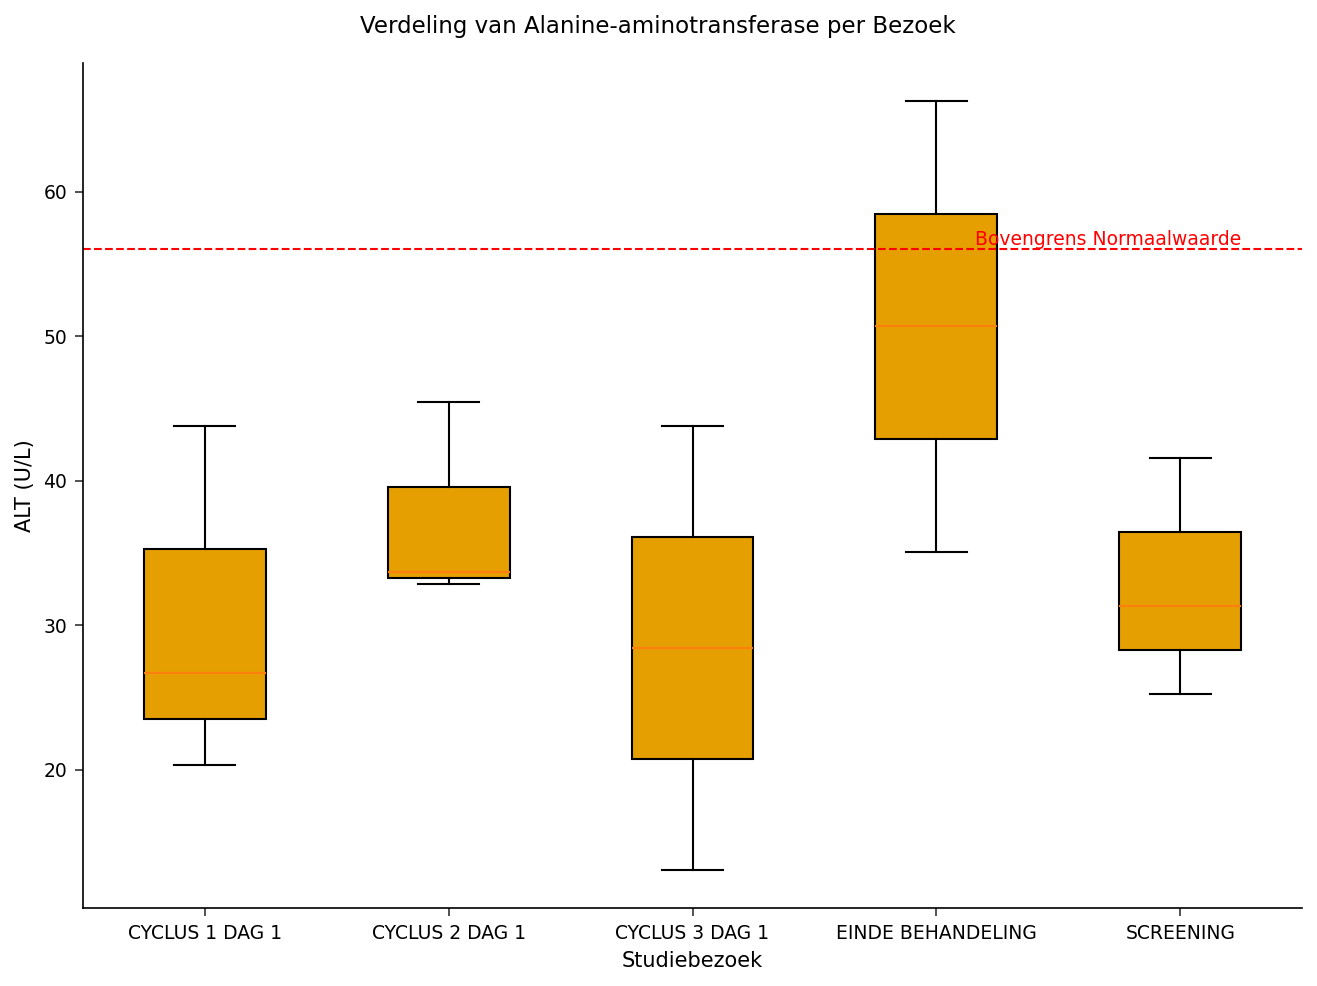

In [5]:
/* --------------------------------------------------------
   Boxplot van ALT-waarden per bezoek
   -------------------------------------------------------- */
PROCEDURE SGPLOT GEGEVENS=work.lab_import;
    WAAR lbtestcd = 'ALT';
    VBOX lbstresn / category=visit;
    REFLINE 56 / AXIS=y LINEATTRS=(pattern=dash color=red)
        label='Bovengrens Normaalwaarde';
    XAXIS label='Studiebezoek';
    YAXIS label='ALT (U/L)';
    TITEL 'Verdeling van Alanine-aminotransferase per Bezoek';
UITVOEREN;


In [6]:
/* --------------------------------------------------------
   Referentiebereikanalyse via PROC MEANS met ODS OUTPUT
   Gestratificeerd naar analyt en bezoek voor beoordeling
   door de medisch monitor
   -------------------------------------------------------- */
PROCEDURE GEMIDDELDEN GEGEVENS=work.lab_import n mean std MIN MAX;
    KLASSE lbtestcd visit;
    VARIABELE lbstresn;
    label lbstresn="Resultaatwaarde" lbtestcd="Testcode" visit="Studiebezoek";
    UITVOER out=work.lab_range_summary
        n=n_obs mean=mean_value std=std_value
        MIN=min_value MAX=max_value;
UITVOEREN;


                                                  The MEANS Procedure

                                      Analysis Variable : lbstresn Resultaatwaarde

        Testcode  Studiebezoek               N Obs           Mean        Std Dev        Minimum        Maximum
        ------------------------------------------------------------------------------------------------------
        ALB       CYCLUS 1 DAG 1                 3      4.2666667      0.5577036      3.6800000      4.7900000
        ALB       CYCLUS 2 DAG 1                 2      4.0450000      0.0636396      4.0000000      4.0900000
        ALB       CYCLUS 3 DAG 1                 2      4.0500000      0.4101219      3.7600000      4.3400000
        ALB       EINDE BEHANDELING              2      4.8200000      0.3676955      4.5600000      5.0800000
        ALB       SCREENING                      3      4.1666667      0.8533073      3.3600000      5.0600000
        ALT       CYCLUS 1 DAG 1                 3     30.2766667   


NOTE: PROC MEANS
NOTE: Output dataset work.lab_range_summary has 54 observations and 9 variables.
NOTE: PROC MEANS statement used.


                                                   The FREQ Procedure

Table of Testcode by Afwijkingsstatus

Testcode |      HOOG |      LAAG |   NORMAAL |      Total
---------+-----------+-----------+-----------+-----------
ALB      |         0 |         1 |        11 |         12
---------+-----------+-----------+-----------+-----------
ALT      |         1 |         0 |        12 |         13
---------+-----------+-----------+-----------+-----------
AST      |         0 |         1 |        12 |         13
---------+-----------+-----------+-----------+-----------
BILI     |         0 |         0 |        13 |         13
---------+-----------+-----------+-----------+-----------
CREAT    |         0 |         0 |        13 |         13
---------+-----------+-----------+-----------+-----------
HGB      |         0 |         0 |        12 |         12
---------+-----------+-----------+-----------+-----------
PLT      |         1 |         0 |        11 |         12
---------+----------


NOTE: DATA work.lab_flagged


NOTE: Read 100 rows from work.lab_import.
NOTE: Wrote work.lab_flagged (100 rows, 16 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_lbtestcd_abnormal_flag.spec.json
NOTE: PROC FREQ statement used.


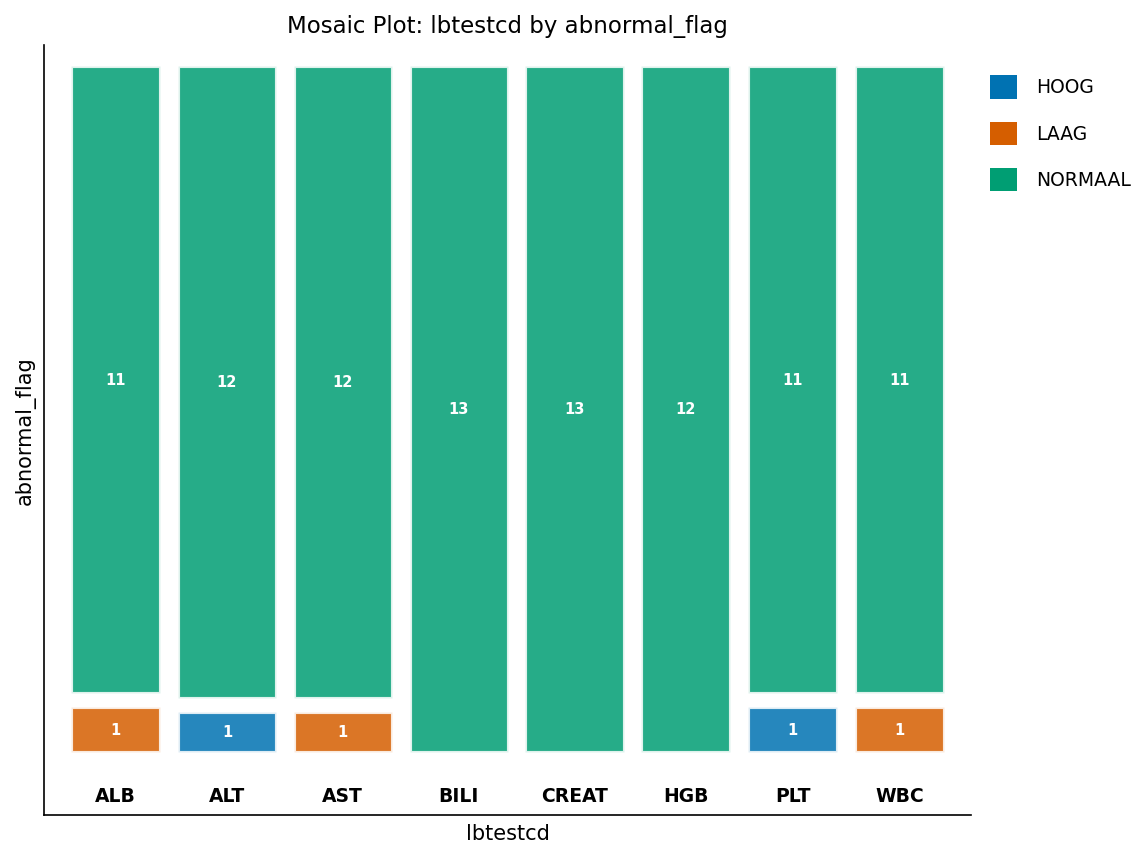

In [7]:
/* --------------------------------------------------------
   Markeer resultaten buiten het referentiebereik
   -------------------------------------------------------- */
GEGEVENS work.lab_flagged;
    INSTELLEN work.lab_import;
    low_ref = input(lbornrlo, best.);
    high_ref = input(lbornrhi, best.);
    ALS lbstresn < low_ref DAN abnormal_flag = 'LAAG';
    ANDERS ALS lbstresn > high_ref DAN abnormal_flag = 'HOOG';
    ANDERS abnormal_flag = 'NORMAAL';
UITVOEREN;

PROCEDURE FREQUENTIES GEGEVENS=work.lab_flagged;
    TABLES lbtestcd * abnormal_flag / nocum nopercent;
    label lbtestcd="Testcode" abnormal_flag="Afwijkingsstatus";
UITVOEREN;


---

### Interpretatie

PROC IMPORT nam de centrale laboratoriumrecords uit het CSV-bestand op; de
sandbox draait in de licentievrije modus, die de invoer en uitvoer begrenst
tot 100 waarnemingen in plaats van de ontworpen 5.000, dus alle onderstaande
cijfers weerspiegelen deze steekproef van 100 rijen. GUESSINGROWS=MAX liet de
lezer elke beschikbare rij scannen voordat de kolomtypen werden vastgelegd,
zodat LBSTRESN, LBORNRLO, LBORNRHI en LBORRES als numeriek werden afgeleid.
PROC CONTENTS bevestigt 13 variabelen (6 numeriek, 7 karakter) voor deze
steekproef. De referentiebereikanalyse geeft een gemiddelde ALT van 35,3 E/L
(SD 13,4) en een gemiddelde AST van 22,2 E/L (SD 9,7), beide binnen de
normaalwaarden; de boxplot toont ALT-verdelingen die per bezoek variëren
binnen deze kleine steekproef, met één waarde boven de bovengrens van de
normaalwaarde van 56 E/L (bij Einde Behandeling). Over de steekproef van 100
resultaten vallen 5 resultaten (5,0%) buiten hun referentiebereik. De
afwijkende markeringen zijn het hoogst bij ALB, PLT en WBC (elk 8,3%),
gevolgd door ALT en AST (elk 7,7%), en 0% bij BILI, CREAT en HGB — een
verdeling die past bij symmetrische variatie rond het referentiemidden van
elke analyt op deze schaal. Deze samenvattingsstatistieken per analyt en per
bezoek zijn het artefact dat een medisch monitor zou screenen op labsignalen
zodra echte studiegegevens het gegenereerde extract vervangen; op
productieschaal (5.000 records) zou de licentievrije beperking niet gelden.

---

In [8]:
/* --------------------------------------------------------
   Exporteer de labbereiksamenvatting voor het rapport
   aan de medisch monitor
   -------------------------------------------------------- */
PROCEDURE EXPORTEREN GEGEVENS=work.lab_range_summary
    OUTFILE='lab_reference_range_summary.csv'
    DBMS=csv REPLACE;
UITVOEREN;



NOTE: PROC EXPORT data=work.lab_range_summary outfile=lab_reference_range_summary.csv

NOTE: Exported 54 rows to lab_reference_range_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>